# FGSM adversarial fine-tuning ResNet18 на Imagewoof

Структура соответствует `code_templates/lightning_template.ipynb`. Подключите Imagewoof и исходные веса через Kaggle Add Input, затем укажите пути в конфигурации.

In [8]:
!pip install lightning -q

In [21]:
from pathlib import Path
import tarfile
import copy
import csv
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
from torchvision.utils import save_image

SEED = 42
L.seed_everything(SEED)
IMAGEWOOF_INPUT = Path('/kaggle/input/datasets/renrgaming2000/imagewoof2-329/imagewoof2-320.tgz')  # папка Kaggle Input или прямой путь к .tgz/.tar.gz
IMAGEWOOF_EXTRACT_DIR = Path('/tmp/imagewoof_extracted')
WEIGHTS_PATH = Path('/kaggle/input/datasets/notquartzz/weights-aa/resnet18_imagewoof_best.pth')  # исходные веса
OUTPUT_DIR = Path('/kaggle/working/imagewoof_fgsm_finetuning')
OUTPUT_WEIGHTS = OUTPUT_DIR / 'resnet18_imagewoof_fgsm_robust.pth'
BATCH_SIZE, NUM_WORKERS = 64, 2
FINETUNE_EPOCHS = 5
LEARNING_RATE, WEIGHT_DECAY = 1e-4, 0.05
TRAIN_EPSILON = 4 / 255
CLEAN_LOSS_WEIGHT = 0.5
ROBUST_EVAL_SAMPLES = 1000
FGSM_EPSILONS = [2, 4, 8]
PGD_EPSILONS, PGD_STEPS = [2, 4], 10
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Device:', DEVICE)

Seed set to 42


Device: cuda


# Загрузка датасета, DataModule

In [3]:
class ImagewoofDataModule(L.LightningDataModule):
    def __init__(self, input_path, batch_size=64, num_workers=2, image_size=224, extract_dir='/tmp/imagewoof_extracted'):
        super().__init__()
        self.input_path = Path(input_path)
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.image_size = image_size
        self.extract_dir = Path(extract_dir)
        self.train_transform = transforms.Compose([
            transforms.RandomResizedCrop(image_size), transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
        ])
        self.val_transform = transforms.Compose([
            transforms.Resize(256), transforms.CenterCrop(image_size), transforms.ToTensor(),
        ])

    def _resolve_root(self, search_path=None):
        search_path = Path(search_path or self.input_path)
        if (search_path/'train').is_dir() and (search_path/'val').is_dir():
            return search_path
        candidates = sorted(
            path.parent for path in search_path.rglob('train')
            if path.is_dir() and (path.parent/'val').is_dir()
        ) if search_path.exists() and search_path.is_dir() else []
        preferred = [path for path in candidates if 'imagewoof' in str(path).lower()]
        if len(preferred) == 1: return preferred[0]
        if len(candidates) == 1: return candidates[0]
        raise FileNotFoundError(f'Не найден единственный Imagewoof train/val в {search_path}: {candidates}')

    def _resolve_archive(self):
        if self.input_path.is_file() and (self.input_path.name.endswith('.tgz') or self.input_path.name.endswith('.tar.gz')):
            return self.input_path
        archives = sorted(set(self.input_path.rglob('*.tgz')) | set(self.input_path.rglob('*.tar.gz')))
        preferred = [path for path in archives if 'imagewoof' in path.name.lower()]
        if len(preferred) == 1: return preferred[0]
        if len(archives) == 1: return archives[0]
        raise FileNotFoundError(f'Не найден единственный архив Imagewoof в {self.input_path}: {archives}')

    def prepare_data(self):
        try:
            self.data_root = self._resolve_root()
            return
        except FileNotFoundError:
            pass
        archive_path = self._resolve_archive()
        try:
            self.data_root = self._resolve_root(self.extract_dir)
            print(f'Используется уже распакованный датасет: {self.data_root}')
            return
        except FileNotFoundError:
            self.extract_dir.mkdir(parents=True, exist_ok=True)
        print(f'Распаковка {archive_path} в {self.extract_dir} ...')
        with tarfile.open(archive_path, 'r:*') as archive:
            archive.extractall(self.extract_dir, filter='data')
        self.data_root = self._resolve_root(self.extract_dir)
        print(f'Датасет распакован: {self.data_root}')

    def setup(self, stage=None):
        if not hasattr(self, 'data_root'):
            self.prepare_data()
        self.train_set = datasets.ImageFolder(self.data_root/'train', transform=self.train_transform)
        self.val_set = datasets.ImageFolder(self.data_root/'val', transform=self.val_transform)
        if self.train_set.class_to_idx != self.val_set.class_to_idx:
            raise ValueError('Порядок классов train и val не совпадает.')
        if len(self.train_set.classes) != 10:
            raise ValueError(f'Ожидалось 10 классов, найдено {len(self.train_set.classes)}.')

    def train_dataloader(self):
        return DataLoader(self.train_set, batch_size=self.batch_size, shuffle=True,
            num_workers=self.num_workers, pin_memory=True,
            persistent_workers=self.num_workers > 0, drop_last=False)

    def val_dataloader(self):
        return DataLoader(self.val_set, batch_size=self.batch_size, shuffle=False,
            num_workers=self.num_workers, pin_memory=True,
            persistent_workers=self.num_workers > 0, drop_last=False)

dm = ImagewoofDataModule(IMAGEWOOF_INPUT, BATCH_SIZE, NUM_WORKERS, extract_dir=IMAGEWOOF_EXTRACT_DIR)
dm.prepare_data(); dm.setup()
sample_x, sample_y = next(iter(dm.val_dataloader()))
assert tuple(sample_x.shape[1:]) == (3, 224, 224)
assert sample_x.min().item() >= 0 and sample_x.max().item() <= 1
print(f'Root: {dm.data_root} | train: {len(dm.train_set):,} | val: {len(dm.val_set):,}')
print('Classes:', dm.train_set.class_to_idx)

Распаковка /kaggle/input/datasets/renrgaming2000/imagewoof2-329/imagewoof2-320.tgz в /tmp/imagewoof_extracted ...
Датасет распакован: /tmp/imagewoof_extracted/imagewoof2-320
Root: /tmp/imagewoof_extracted/imagewoof2-320 | train: 9,025 | val: 3,929
Classes: {'n02086240': 0, 'n02087394': 1, 'n02088364': 2, 'n02089973': 3, 'n02093754': 4, 'n02096294': 5, 'n02099601': 6, 'n02105641': 7, 'n02111889': 8, 'n02115641': 9}


# LightningModule и исходные веса

In [9]:
class Normalize(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer('mean', torch.tensor(mean).view(1, -1, 1, 1))
        self.register_buffer('std', torch.tensor(std).view(1, -1, 1, 1))
    def forward(self, x): return (x - self.mean) / self.std

class NormalizedModel(nn.Module):
    def __init__(self, model, mean, std):
        super().__init__(); self.normalize = Normalize(mean, std); self.model = model
    def forward(self, x): return self.model(self.normalize(x))

class ImagewoofAdversarialClassifier(L.LightningModule):
    def __init__(self, num_classes=10, lr=1e-4, weight_decay=0.05, max_epochs=5,
                 epsilon=4/255, clean_loss_weight=0.5,
                 mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)):
        super().__init__(); self.save_hyperparameters()
        self.model = NormalizedModel(models.resnet18(weights=None, num_classes=num_classes), mean, std)

    def forward(self, x): return self.model(x)

    def make_fgsm(self, x, y):
        was_training = self.training; self.eval()
        with torch.enable_grad():
            x_adv = x.detach().clone().requires_grad_(True)
            gradient = torch.autograd.grad(F.cross_entropy(self(x_adv), y), x_adv)[0]
            x_adv = (x_adv + self.hparams.epsilon*gradient.sign()).clamp(0,1).detach()
        if was_training: self.train()
        return x_adv

    def training_step(self, batch, batch_idx):
        x, y = batch; x_adv = self.make_fgsm(x, y)
        clean_logits, adv_logits = self(x), self(x_adv)
        clean_loss = F.cross_entropy(clean_logits, y)
        adv_loss = F.cross_entropy(adv_logits, y)
        loss = self.hparams.clean_loss_weight*clean_loss + (1-self.hparams.clean_loss_weight)*adv_loss
        self.log('train_loss', loss, on_epoch=True, batch_size=y.size(0))
        self.log('train_clean_acc', (clean_logits.argmax(1)==y).float().mean(), on_epoch=True, batch_size=y.size(0))
        self.log('train_fgsm_acc', (adv_logits.argmax(1)==y).float().mean(), on_epoch=True, batch_size=y.size(0))
        self.log('lr', self.trainer.optimizers[0].param_groups[0]['lr'], on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch; clean_logits = self(x); x_adv = self.make_fgsm(x, y); adv_logits = self(x_adv)
        self.log('val_loss', F.cross_entropy(clean_logits,y), on_epoch=True, sync_dist=True, batch_size=y.size(0))
        self.log('val_acc', (clean_logits.argmax(1)==y).float().mean(), on_epoch=True, sync_dist=True, batch_size=y.size(0))
        self.log('val_fgsm_acc', (adv_logits.argmax(1)==y).float().mean(), on_epoch=True, sync_dist=True, batch_size=y.size(0))

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.hparams.max_epochs)
        return {'optimizer': optimizer, 'lr_scheduler': {'scheduler': scheduler, 'interval': 'epoch'}}

def load_initial_weights(lightning_model, weights_path):
    if not weights_path.is_file(): raise FileNotFoundError(f'Не найдены веса: {weights_path}')
    checkpoint = torch.load(weights_path, map_location='cpu', weights_only=True)
    state = checkpoint.get('state_dict', checkpoint.get('model_state_dict', checkpoint))
    state = {k.removeprefix('module.'): v for k,v in state.items()}
    if any(k.startswith('model.model.') for k in state):
        state = {k.removeprefix('model.'): v for k,v in state.items()}
    if 'normalize.mean' in state and any(k.startswith('model.') for k in state):
        lightning_model.model.load_state_dict(state, strict=True)
    else:
        state = {k.removeprefix('backbone.'): v for k,v in state.items()
                 if k not in {'normalize.mean', 'normalize.std'}}
        lightning_model.model.model.load_state_dict(state, strict=True)
    return copy.deepcopy(lightning_model.model.model.state_dict())

model = ImagewoofAdversarialClassifier(num_classes=10, lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY, max_epochs=FINETUNE_EPOCHS,
    epsilon=TRAIN_EPSILON, clean_loss_weight=CLEAN_LOSS_WEIGHT)
initial_raw_state = load_initial_weights(model, WEIGHTS_PATH)
print('Weights loaded:', WEIGHTS_PATH)

Weights loaded: /kaggle/input/datasets/notquartzz/weights-aa/resnet18_imagewoof_best.pth


# Smoke-тест

Используется отдельный экземпляр, поэтому smoke-тест не изменяет основные веса.

In [10]:
smoke_model = ImagewoofAdversarialClassifier(num_classes=10, lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY, max_epochs=FINETUNE_EPOCHS,
    epsilon=TRAIN_EPSILON, clean_loss_weight=CLEAN_LOSS_WEIGHT)
smoke_model.model.model.load_state_dict(initial_raw_state, strict=True)
smoke_trainer = L.Trainer(fast_dev_run=True, accelerator='auto', devices=1,
    inference_mode=False, logger=False, enable_checkpointing=False)
smoke_trainer.fit(smoke_model, datamodule=dm)
del smoke_model, smoke_trainer
if torch.cuda.is_available(): torch.cuda.empty_cache()
print('Smoke-тест пройден')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Используется уже распакованный датасет: /tmp/imagewoof_extracted/imagewoof2-320


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ NormalizedModel │ 11.2 M │ train │     0 │
└───┴───────┴─────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44.727                                                                     
Modules in train mode: 70                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

`Trainer.fit` stopped: `max_steps=1` reached.


Smoke-тест пройден


# FGSM adversarial fine-tuning

In [11]:
checkpoint_callback = ModelCheckpoint(dirpath=OUTPUT_DIR/'checkpoints',
    monitor='val_fgsm_acc', mode='max', save_top_k=1,
    filename='best-{epoch:02d}-{val_fgsm_acc:.4f}')
trainer = L.Trainer(devices=1, max_epochs=model.hparams.max_epochs, accelerator='auto',
    precision='16-mixed', inference_mode=False, callbacks=[checkpoint_callback])
trainer.fit(model, datamodule=dm)
print('Best checkpoint:', checkpoint_callback.best_model_path)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Используется уже распакованный датасет: /tmp/imagewoof_extracted/imagewoof2-320


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ NormalizedModel │ 11.2 M │ train │     0 │
└───┴───────┴─────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44.727                                                                     
Modules in train mode: 70                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=5` reached.


Best checkpoint: /kaggle/working/imagewoof_fgsm_finetuning/checkpoints/best-epoch=04-val_fgsm_acc=0.1868.ckpt


# FGSM и PGD: сравнение до и после

In [15]:
def fgsm_attack(net, x, y, epsilon):
    if epsilon == 0: return x.detach().clone()
    x_adv = x.detach().clone().requires_grad_(True)
    grad = torch.autograd.grad(F.cross_entropy(net(x_adv),y), x_adv)[0]
    return (x_adv + epsilon*grad.sign()).clamp(0,1).detach()

def pgd_attack(net, x, y, epsilon, steps=10):
    if epsilon == 0: return x.detach().clone()
    original = x.detach(); x_adv = (original+torch.empty_like(original).uniform_(-epsilon,epsilon)).clamp(0,1)
    for _ in range(steps):
        x_adv.requires_grad_(True)
        grad = torch.autograd.grad(F.cross_entropy(net(x_adv),y), x_adv)[0]
        with torch.no_grad():
            x_adv = x_adv + (epsilon/4)*grad.sign()
            x_adv = (original+(x_adv-original).clamp(-epsilon,epsilon)).clamp(0,1)
    return x_adv.detach()

@torch.no_grad()
def clean_accuracy(net, loader):
    net.eval(); correct=total=0
    for x,y in loader:
        x,y=x.to(DEVICE),y.to(DEVICE); correct+=(net(x).argmax(1)==y).sum().item(); total+=y.size(0)
    return correct/total

def robust_accuracy(net, loader, attack, epsilon, max_samples):
    net.eval(); correct=clean_correct=successful=total=0
    for x,y in loader:
        remaining=max_samples-total
        if remaining<=0: break
        x,y=x[:remaining].to(DEVICE),y[:remaining].to(DEVICE)
        with torch.no_grad(): clean_pred=net(x).argmax(1)
        with torch.enable_grad(): x_adv=attack(net,x,y,epsilon)
        with torch.no_grad(): adv_pred=net(x_adv).argmax(1)
        clean_mask=clean_pred.eq(y); correct+=adv_pred.eq(y).sum().item()
        clean_correct+=clean_mask.sum().item(); successful+=(clean_mask & adv_pred.ne(y)).sum().item(); total+=y.size(0)
    return {'robust_accuracy':correct/total, 'attack_success_rate':successful/clean_correct if clean_correct else 0.0, 'samples':total}

baseline_module = ImagewoofAdversarialClassifier()
baseline_module.model.model.load_state_dict(initial_raw_state, strict=True)
baseline = baseline_module.model.to(DEVICE).eval().requires_grad_(False)
best_model = ImagewoofAdversarialClassifier.load_from_checkpoint(checkpoint_callback.best_model_path, map_location=DEVICE)
robust_model = best_model.model.to(DEVICE).eval().requires_grad_(False)
val_loader = dm.val_dataloader(); results=[]
for model_name, net in [('before',baseline),('after',robust_model)]:
    results.append({'model':model_name,'attack':'clean','epsilon':0,
        'robust_accuracy':clean_accuracy(net,val_loader),'attack_success_rate':0.0,'samples':len(dm.val_set)})
    for eps in FGSM_EPSILONS:
        metrics=robust_accuracy(net,val_loader,fgsm_attack,eps/255,ROBUST_EVAL_SAMPLES)
        results.append({'model':model_name,'attack':'FGSM','epsilon':eps,**metrics})
        print(f'{model_name:>6} FGSM {eps}/255: {metrics["robust_accuracy"]*100:.2f}%')
    for eps in PGD_EPSILONS:
        attack=lambda m,x,y,e:pgd_attack(m,x,y,e,PGD_STEPS)
        metrics=robust_accuracy(net,val_loader,attack,eps/255,ROBUST_EVAL_SAMPLES)
        results.append({'model':model_name,'attack':f'PGD-{PGD_STEPS}','epsilon':eps,**metrics})
        print(f'{model_name:>6} PGD {eps}/255: {metrics["robust_accuracy"]*100:.2f}%')

before FGSM 2/255: 17.30%
before FGSM 4/255: 11.80%
before FGSM 8/255: 9.30%
before PGD 2/255: 2.00%
before PGD 4/255: 0.10%
 after FGSM 2/255: 39.50%
 after FGSM 4/255: 17.90%
 after FGSM 8/255: 5.00%
 after PGD 2/255: 31.60%
 after PGD 4/255: 6.30%


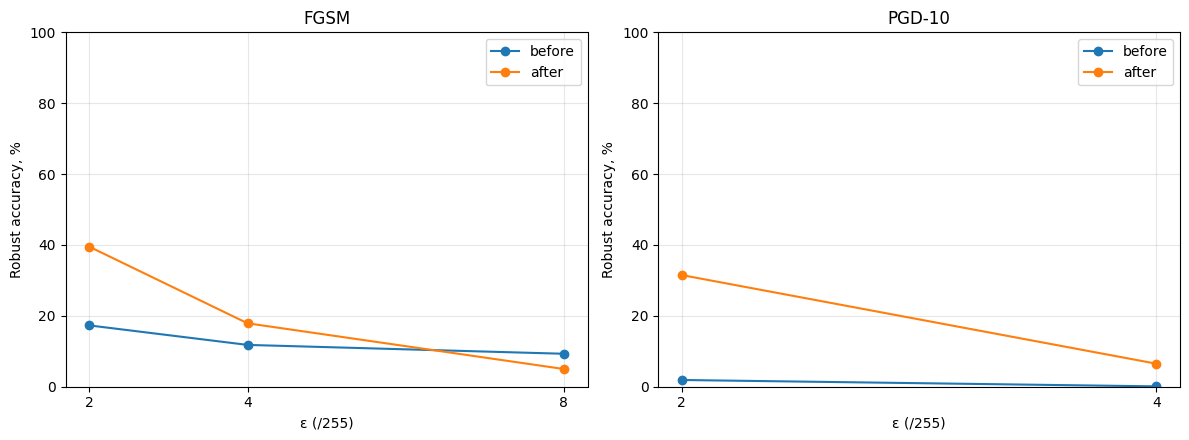

In [14]:
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
for axis,attack_name,eps_values in zip(axes,['FGSM',f'PGD-{PGD_STEPS}'],[FGSM_EPSILONS,PGD_EPSILONS]):
    for model_name in ('before','after'):
        rows=[r for r in results if r['model']==model_name and r['attack']==attack_name]
        axis.plot([r['epsilon'] for r in rows],[r['robust_accuracy']*100 for r in rows],marker='o',label=model_name)
    axis.set_title(attack_name); axis.set_xlabel('ε (/255)'); axis.set_ylabel('Robust accuracy, %')
    axis.set_xticks(eps_values); axis.set_ylim(0,100); axis.grid(alpha=.3); axis.legend()
fig.tight_layout(); fig.savefig(OUTPUT_DIR/'robustness_comparison.png',dpi=160); plt.show()

# Примеры изображений после атак


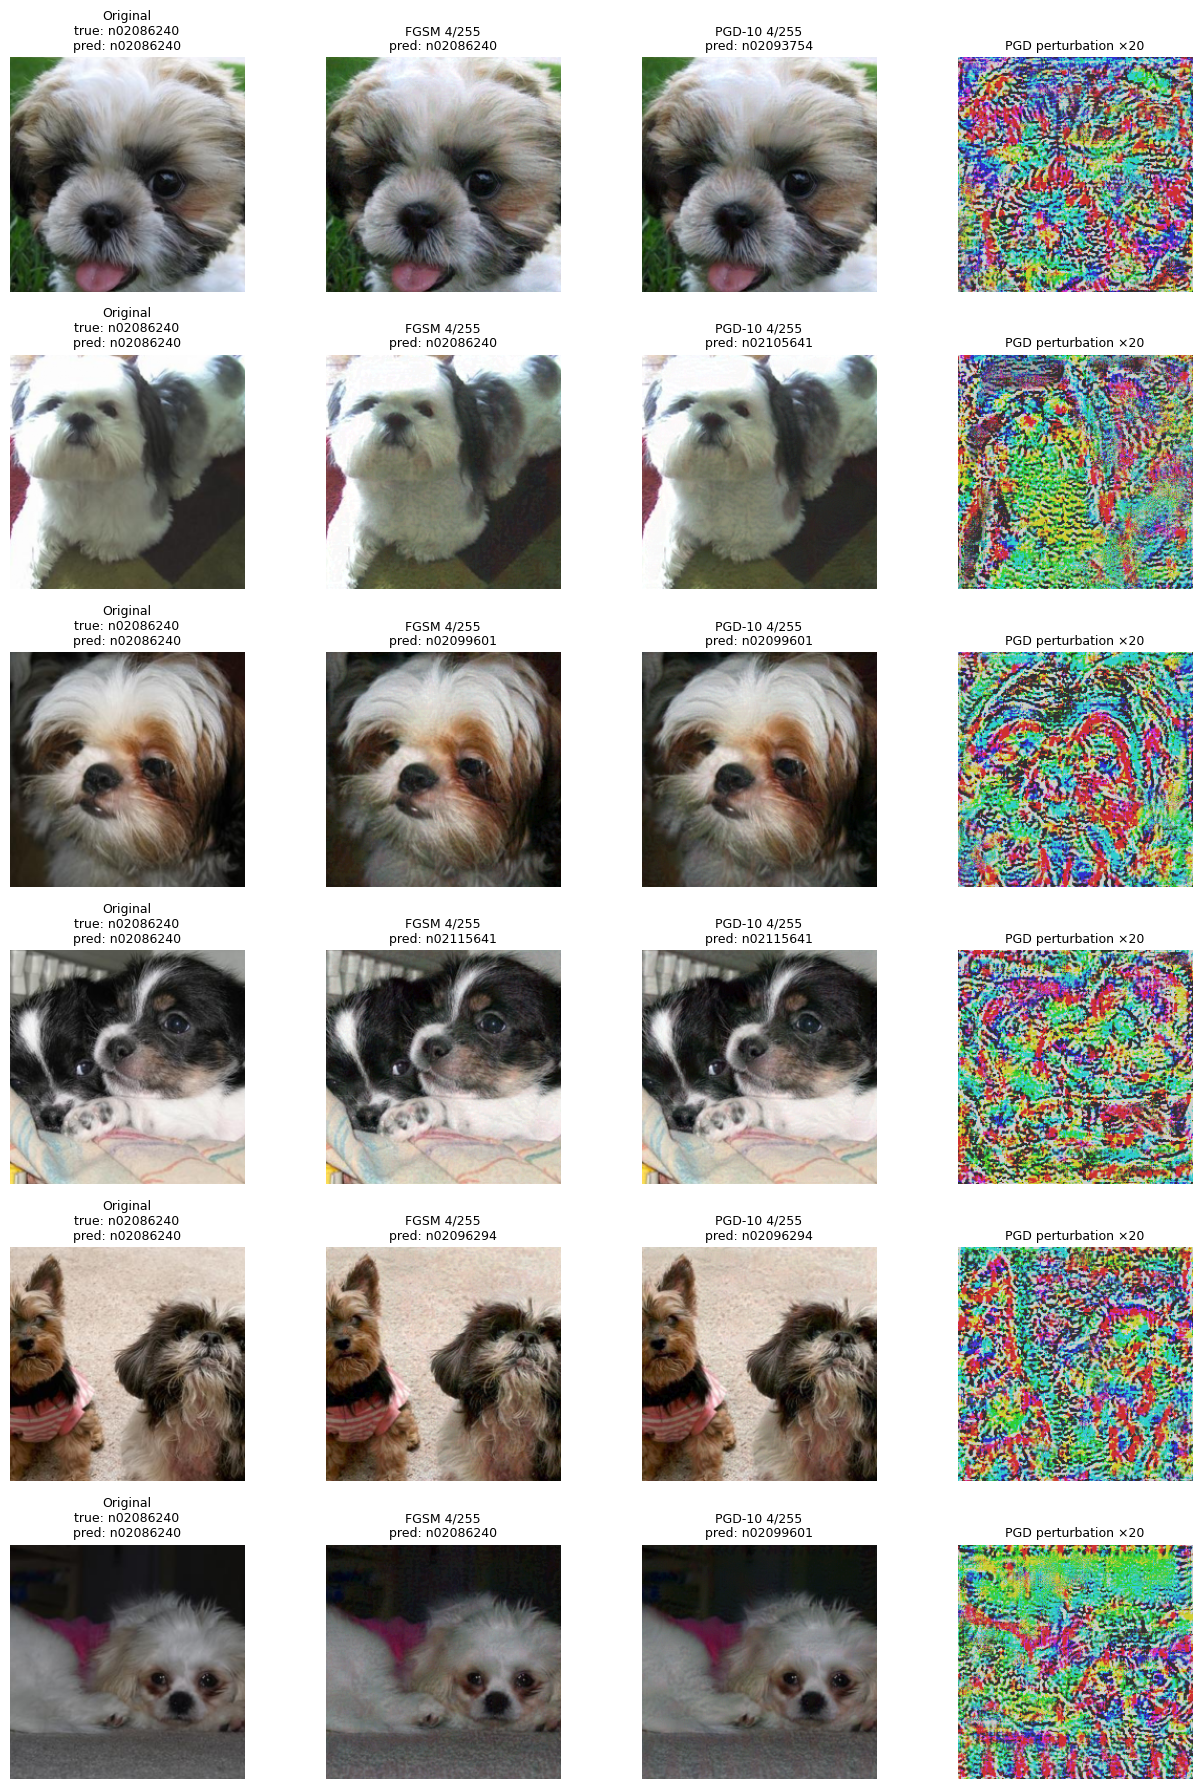

In [22]:
VIS_EPSILON = 4 / 255
NUM_EXAMPLES = 6

robust_model = robust_model.to(DEVICE).eval()
x_vis, y_vis = next(iter(val_loader))
x_vis, y_vis = x_vis[:NUM_EXAMPLES].to(DEVICE), y_vis[:NUM_EXAMPLES].to(DEVICE)
with torch.enable_grad():
    x_fgsm = fgsm_attack(robust_model, x_vis, y_vis, VIS_EPSILON)
    x_pgd = pgd_attack(robust_model, x_vis, y_vis, VIS_EPSILON, PGD_STEPS)
with torch.no_grad():
    pred_clean = robust_model(x_vis).argmax(1)
    pred_fgsm = robust_model(x_fgsm).argmax(1)
    pred_pgd = robust_model(x_pgd).argmax(1)

class_names = dm.val_set.classes
examples_dir = OUTPUT_DIR / 'adversarial_examples'
examples_dir.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(NUM_EXAMPLES, 4, figsize=(13, 3 * NUM_EXAMPLES))
for row in range(NUM_EXAMPLES):
    true_name = class_names[y_vis[row].item()]
    images = [
        x_vis[row],
        x_fgsm[row],
        x_pgd[row],
        (0.5 + 20 * (x_pgd[row] - x_vis[row])).clamp(0, 1),
    ]
    image_names = ['original', 'fgsm', f'pgd{PGD_STEPS}', 'pgd_perturbation_x20']
    for image_name, image in zip(image_names, images):
        save_image(image.detach().cpu(), examples_dir / f'{row:02d}_{image_name}_true-{y_vis[row].item()}.png')
    titles = [
        f'Original\ntrue: {true_name}\npred: {class_names[pred_clean[row].item()]}',
        f'FGSM {VIS_EPSILON * 255:.0f}/255\npred: {class_names[pred_fgsm[row].item()]}',
        f'PGD-{PGD_STEPS} {VIS_EPSILON * 255:.0f}/255\npred: {class_names[pred_pgd[row].item()]}',
        'PGD perturbation ×20',
    ]
    for axis, image, title in zip(axes[row], images, titles):
        axis.imshow(image.detach().cpu().permute(1, 2, 0).numpy())
        axis.set_title(title, fontsize=9)
        axis.axis('off')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'adversarial_examples.png', dpi=160, bbox_inches='tight')
plt.show()

# Сохранение весов и метрик

In [16]:
torch.save(best_model.model.cpu().state_dict(), OUTPUT_WEIGHTS)
with (OUTPUT_DIR/'robustness_metrics.csv').open('w',newline='',encoding='utf-8') as file:
    writer=csv.DictWriter(file,fieldnames=results[0].keys()); writer.writeheader(); writer.writerows(results)
print('Saved:')
for path in sorted(OUTPUT_DIR.rglob('*')):
    if path.is_file(): print(' ',path)

Saved:
  /kaggle/working/imagewoof_fgsm_finetuning/checkpoints/best-epoch=04-val_fgsm_acc=0.1868.ckpt
  /kaggle/working/imagewoof_fgsm_finetuning/resnet18_imagewoof_fgsm_robust.pth
  /kaggle/working/imagewoof_fgsm_finetuning/robustness_comparison.png
  /kaggle/working/imagewoof_fgsm_finetuning/robustness_metrics.csv
